# Project 2: Predicting Restaurant Inspection Score Change

**Question:** Given a restaurant's most recent routine inspection, construct a valid prediction interval for how much its inspection score will change at its next routine inspection — using only information available at the time of the current inspection.

**Pipeline:**
- **Phase 1 (Inference):** Knockoffs for FDR-controlled feature selection + FCR confidence intervals on selected features
- **Phase 2 (Predictive Inference):** Conformalized Quantile Regression (CQR) with clustered Jackknife+ for prediction intervals
- **Evaluation:** Coverage and interval width on 2019 holdout data

## Setup

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

ALPHA = 0.1   # target miscoverage rate -> intervals target >= 1 - 2*alpha = 80% (jackknife+)
FDR_LEVEL = 0.2  # knockoff FDR level (raised from 0.2: with ~3 true predictors
                  # and 10 features, FDR=0.2 requires ≥5 clean true discoveries
                  # which is impossible; FDR=0.4 requires ≥2.5, achievable)

## Step 1: Preprocessing

In [120]:
raw_data = pd.read_csv('../restaurantdata.csv')
print(f'Raw data shape: {raw_data.shape}')
print(raw_data.dtypes)

Raw data shape: (53973, 17)
business_id                int64
business_name             object
business_address          object
business_city             object
business_state            object
business_postal_code      object
business_latitude        float64
business_longitude       float64
business_location         object
business_phone_number    float64
inspection_id             object
inspection_date           object
inspection_score         float64
inspection_type           object
violation_id              object
violation_description     object
risk_category             object
dtype: object


In [121]:
df = raw_data.copy()

# (1) Non-missing inspection score
df = df[df['inspection_score'].notna()].copy()
df['inspection_score'] = pd.to_numeric(df['inspection_score'], errors='coerce')
df = df[df['inspection_score'].notna()].copy()

# (2) Parse date
df['inspection_date'] = pd.to_datetime(
    df['inspection_date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce'
)
df = df[df['inspection_date'].notna()].copy()
df['month'] = df['inspection_date'].dt.month
df['day']   = df['inspection_date'].dt.day
df['year']  = df['inspection_date'].dt.year

# (3) Replace empty risk_category with 'None'
df['risk_category'] = df['risk_category'].replace('', 'None')

# Rename columns to match data1
df = df.rename(columns={
    'business_postal_code': 'zipcode',
    'business_latitude':    'latitude',
    'business_longitude':   'longitude'
})

df = df.sort_values(['business_id', 'inspection_date']).reset_index(drop=True)

data1 = df[['month', 'day', 'year', 'business_id', 'risk_category',
            'inspection_score', 'zipcode', 'latitude', 'longitude',
            'inspection_date']].copy()

print(f'data1 shape: {data1.shape}')
print(f'Unique inspections (business_id + date): {data1.groupby(["business_id","inspection_date"]).ngroups}')
data1.head(10)

data1 shape: (39541, 10)
Unique inspections (business_id + date): 14031


,month,day,year,business_id,risk_category,inspection_score,zipcode,latitude,longitude,inspection_date
0,12,11,2017,19,Low Risk,94.0,94109,37.786848,-122.421547,2017-12-11
1,12,11,2017,19,Moderate Risk,94.0,94109,37.786848,-122.421547,2017-12-11
2,6,7,2018,19,Moderate Risk,96.0,94109,37.786848,-122.421547,2018-06-07
3,10,5,2016,24,NaN,98.0,94104,37.792888,-122.403135,2016-10-05
4,11,1,2017,24,Low Risk,98.0,94104,37.792888,-122.403135,2017-11-01
5,5,1,2019,24,Low Risk,98.0,94104,37.792888,-122.403135,2019-05-01
6,6,15,2018,31,Low Risk,96.0,94133,37.807155,-122.419004,2018-06-15
7,6,15,2018,31,Low Risk,96.0,94133,37.807155,-122.419004,2018-06-15
8,7,2,2019,31,Moderate Risk,94.0,94133,37.807155,-122.419004,2019-07-02
9,7,2,2019,31,Low Risk,94.0,94133,37.807155,-122.419004,2019-07-02


Each inspection can have multiple rows (one per violation). We aggregate risk categories into binary features.

In [122]:
inspections = (
    data1
    .groupby(['business_id', 'inspection_date', 'month', 'day', 'year',
              'zipcode', 'latitude', 'longitude'])
    .agg(
        inspection_score = ('inspection_score', 'first'),
        has_low          = ('risk_category', lambda x: int('Low Risk' in x.values)),
        has_moderate     = ('risk_category', lambda x: int('Moderate Risk' in x.values)),
        has_high         = ('risk_category', lambda x: int('High Risk' in x.values)),
        num_violations   = ('risk_category', 'count')
    )
    .reset_index()
    .sort_values(['business_id', 'inspection_date'])
    .reset_index(drop=True)
)

print(f'Unique inspections: {len(inspections)}')
print(f'Unique restaurants: {inspections["business_id"].nunique()}')
inspections.head(8)

Unique inspections: 7297
Unique restaurants: 2683


,business_id,inspection_date,month,day,year,zipcode,latitude,longitude,inspection_score,has_low,has_moderate,has_high,num_violations
0,19,2017-12-11,12,11,2017,94109,37.786848,-122.421547,94.0,1,1,0,2
1,19,2018-06-07,6,7,2018,94109,37.786848,-122.421547,96.0,0,1,0,1
2,24,2016-10-05,10,5,2016,94104,37.792888,-122.403135,98.0,0,0,0,0
3,24,2017-11-01,11,1,2017,94104,37.792888,-122.403135,98.0,1,0,0,1
4,24,2019-05-01,5,1,2019,94104,37.792888,-122.403135,98.0,1,0,0,1
5,31,2018-06-15,6,15,2018,94133,37.807155,-122.419004,96.0,1,0,0,2
6,31,2019-07-02,7,2,2019,94133,37.807155,-122.419004,94.0,1,1,0,2
7,45,2017-03-07,3,7,2017,94110,37.747114,-122.413641,88.0,1,1,0,5


For each restaurant with $\geq 2$ inspections, create all consecutive pairs $(t_k \to t_{k+1})$. Target: $\Delta = \text{score}_{t_{k+1}} - \text{score}_{t_k}$. Restaurants with only one inspection are dropped.

In [147]:
records = []

for biz_id, grp in inspections.groupby('business_id'):
    grp = grp.sort_values('inspection_date').reset_index(drop=True)
    if len(grp) < 2:
        continue
    scores = grp['inspection_score'].values
    for k in range(len(grp) - 1):
        curr = grp.iloc[k]
        nxt  = grp.iloc[k + 1]
        prev_delta = scores[k] - scores[k-1] if k > 0 else 0

        # Historical mean score: mean of all scores BEFORE current inspection
        hist_score_mean = float(np.mean(scores[:k])) if k > 0 else scores[k]

        # Historical mean delta: mean of all consecutive deltas up to and including prev_delta
        #   delta_0 = scores[1]-scores[0], ..., delta_{k-1} = scores[k]-scores[k-1]
        if k > 0:
            hist_score_diff_mean = float(np.mean(np.diff(scores[:k+1])))
        else:
            hist_score_diff_mean = 0

        records.append({
            'business_id':        biz_id,
            'pair_index':         k,
            'curr_date':          curr['inspection_date'],
            'next_date':          nxt['inspection_date'],
            'month':              curr['month'],
            'year':               curr['year'],
            'zipcode':            curr['zipcode'],
            'latitude':           curr['latitude'],
            'longitude':          curr['longitude'],
            'prev_score':         curr['inspection_score'],
            'has_low':            curr['has_low'],
            'has_moderate':       curr['has_moderate'],
            'has_high':           curr['has_high'],
            'num_violations':     curr['num_violations'],
            'time_gap':           (nxt['inspection_date'] - curr['inspection_date']).days,
            'prev_delta':         prev_delta,
            'hist_score_mean':    hist_score_mean,
            'hist_score_diff_mean': hist_score_diff_mean,
            'delta':              nxt['inspection_score'] - curr['inspection_score'],
        })

pairs = pd.DataFrame(records)
print(f'Total consecutive pairs: {len(pairs)}')
print(f'Restaurants contributing pairs: {pairs["business_id"].nunique()}')
print(f'Pairs with prev_delta available:         {pairs["prev_delta"].notna().mean():.1%}')
print(f'Pairs with hist_score_mean available:    {pairs["hist_score_mean"].notna().mean():.1%}')
print(f'Pairs with hist_score_diff_mean available: {pairs["hist_score_diff_mean"].notna().mean():.1%}')
pairs.head(6)


Total consecutive pairs: 4614
Restaurants contributing pairs: 2351
Pairs with prev_delta available:         100.0%
Pairs with hist_score_mean available:    100.0%
Pairs with hist_score_diff_mean available: 100.0%


,business_id,pair_index,curr_date,next_date,month,year,zipcode,latitude,longitude,prev_score,has_low,has_moderate,has_high,num_violations,time_gap,prev_delta,hist_score_mean,hist_score_diff_mean,delta
0,19,0,2017-12-11,2018-06-07,12,2017,94109,37.786848,-122.421547,94.0,1,1,0,2,178,0.0,94.0,0.0,2.0
1,24,0,2016-10-05,2017-11-01,10,2016,94104,37.792888,-122.403135,98.0,0,0,0,0,392,0.0,98.0,0.0,0.0
2,24,1,2017-11-01,2019-05-01,11,2017,94104,37.792888,-122.403135,98.0,1,0,0,1,546,0.0,98.0,0.0,0.0
3,31,0,2018-06-15,2019-07-02,6,2018,94133,37.807155,-122.419004,96.0,1,0,0,2,382,0.0,96.0,0.0,-2.0
4,45,0,2017-03-07,2017-09-14,3,2017,94110,37.747114,-122.413641,88.0,1,1,0,5,191,0.0,88.0,0.0,-3.0
5,45,1,2017-09-14,2018-05-29,9,2017,94110,37.747114,-122.413641,85.0,1,1,1,4,257,-3.0,88.0,-3.0,3.0


We split by `business_id` to ensure Set A and Set B are fully independent. Splitting by pair would allow the same restaurant to appear in both sets, violating independence for knockoffs and conformal prediction.

- **Set A** (50% of 2016-2018 restaurants): knockoffs + FCR CIs
- **Set B** (50% of 2016-2018 restaurants): jackknife+ with CQR
- **Test** (2019, first pair per restaurant): coverage evaluation

In [148]:
# Separate 2019 test set first (pairs whose CURRENT inspection is in 2016-2018
# but next inspection is in 2019)
# More precisely: use pairs where curr_date is in 2016-2018 and next_date is in 2019
pairs_train = pairs[pairs['next_date'].dt.year <= 2018].copy()
pairs_test  = pairs[
    (pairs['curr_date'].dt.year <= 2018) & (pairs['next_date'].dt.year == 2019)
].copy()

print(f'Training pairs (2016-2018): {len(pairs_train)}')
print(f'Test pairs (last 2018 -> first 2019): {len(pairs_test)}')

# For test: keep only the FIRST 2019 pair per restaurant to avoid within-restaurant correlation
pairs_test = (
    pairs_test
    .sort_values(['business_id', 'curr_date'])
    .groupby('business_id')
    .first()
    .reset_index()
)
print(f'Test pairs after dedup (first per restaurant): {len(pairs_test)}')

# Split training restaurants 70/30 into Set A and Set B
# Larger Set A gives knockoffs more signal: true features enter at higher λ,
# their knockoffs enter later, widening the Z_orig - Z_tilde gap.
train_restaurants = pairs_train['business_id'].unique()
np.random.shuffle(train_restaurants)
n_A = int(len(train_restaurants) * 0.7)

rest_A = set(train_restaurants[:n_A])
rest_B = set(train_restaurants[n_A:])

set_A = pairs_train[pairs_train['business_id'].isin(rest_A)].copy()
set_B = pairs_train[pairs_train['business_id'].isin(rest_B)].copy()

print(f'\nSet A: {len(set_A)} pairs from {len(rest_A)} restaurants')
print(f'Set B: {len(set_B)} pairs from {len(rest_B)} restaurants')
print(f'Test:  {len(pairs_test)} pairs from {pairs_test["business_id"].nunique()} restaurants')

Training pairs (2016-2018): 2519
Test pairs (last 2018 -> first 2019): 1819
Test pairs after dedup (first per restaurant): 1819

Set A: 1751 pairs from 1256 restaurants
Set B: 768 pairs from 539 restaurants
Test:  1819 pairs from 1819 restaurants


---
## Step 1: Feature Engineering

Zipcode statistics are computed from **Set A only** and applied as fixed constants to Set B and the test set. This prevents leakage from Set B's target values into the zipcode encoding.

In [149]:
# Compute zipcode statistics from Set A only
zipcode_stats = (
    set_A
    .groupby('zipcode')['prev_score']
    .agg(zipcode_avg_score='mean', zipcode_score_std='std')
    .reset_index()
)
global_std = set_A['prev_score'].std()
zipcode_stats['zipcode_score_std'] = zipcode_stats['zipcode_score_std'].fillna(global_std)

# Leave-one-out (LOO) target encoding for zipcode_avg_delta
zipcode_delta_sum   = set_A.groupby('zipcode')['delta'].sum()
zipcode_delta_count = set_A.groupby('zipcode')['delta'].count()

def loo_zipcode_delta(row):
    z = row['zipcode']
    total = zipcode_delta_sum.get(z, 0)
    count = zipcode_delta_count.get(z, 0)
    if count <= 1:
        return set_A['delta'].mean()
    return (total - row['delta']) / (count - 1)

set_A = set_A.copy()
set_A['zipcode_avg_delta'] = set_A.apply(loo_zipcode_delta, axis=1)

# For Set B and test: use full Set-A zipcode mean (no leakage risk)
zipcode_delta_stats = (
    set_A.groupby('zipcode')['delta'].mean()
    .reset_index().rename(columns={'delta': 'zipcode_avg_delta'})
)
global_avg_delta = set_A['delta'].mean()

print('Zipcode statistics (from Set A):')
print(zipcode_stats.describe())
print(f'\nZipcode avg delta stats:')
print(zipcode_delta_stats['zipcode_avg_delta'].describe())
print(f'Unique zipcodes: {len(zipcode_stats)}')


Zipcode statistics (from Set A):
       zipcode_avg_score  zipcode_score_std
count          28.000000          28.000000
mean           90.956602           7.435250
std             2.635450           1.475559
min            87.620000           2.828427
25%            89.000000           6.676038
50%            90.429315           7.814681
75%            92.031410           8.208706
max            98.000000           9.897773

Zipcode avg delta stats:
count    28.000000
mean      0.746493
std       1.948368
min      -6.000000
25%      -0.152164
50%       0.989796
75%       1.820000
max       5.000000
Name: zipcode_avg_delta, dtype: float64
Unique zipcodes: 28


In [150]:
FEATURE_COLS = [
    'prev_score',
    'has_low', 'has_moderate', 'has_high',
    'num_violations',
    'time_gap',
    'z_score',           # (prev_score - zipcode_avg_score) / zipcode_score_std
                         #   captures regression-to-mean; NOT collinear (denominator varies)
    'zipcode_avg_score',
    'zipcode_avg_delta',
    'prev_delta',
    'hist_score_mean',
    'hist_score_diff_mean',
    'month_avg_delta',   # target encoding: mean delta across dataset for this calendar month
    'year_avg_delta',    # target encoding: mean delta across dataset for this year
    # dropped: 'month', 'year' (raw integers; replaced by target-encoded versions)
    # dropped: 'zipcode_score_std' (weak null feature)
    # dropped: 'score_deviation' (exact linear combo of prev_score - zipcode_avg_score)
]

# ── Compute all encodings from Set A only to avoid leakage ───────────────

global_avg = set_A['prev_score'].mean()

set_A = set_A.merge(zipcode_stats, on='zipcode', how='left')
set_A['zipcode_avg_score'] = set_A['zipcode_avg_score'].fillna(global_avg)
set_A['zipcode_score_std'] = set_A['zipcode_score_std'].fillna(global_std)
set_A['score_deviation']   = set_A['prev_score'] - set_A['zipcode_avg_score']
set_A['z_score']           = set_A['score_deviation'] / set_A['zipcode_score_std'].clip(lower=1e-3)
set_A['prev_delta']        = set_A['prev_delta'].fillna(set_A['zipcode_avg_delta'])
set_A['hist_score_mean']      = set_A['hist_score_mean'].fillna(set_A['prev_score'])
set_A['hist_score_diff_mean'] = set_A['hist_score_diff_mean'].fillna(set_A['zipcode_avg_delta'])

# Month target encoding: leave-one-out mean delta by calendar month
month_delta_sum   = set_A.groupby('month')['delta'].sum()
month_delta_count = set_A.groupby('month')['delta'].count()
global_avg_delta  = set_A['delta'].mean()

def loo_month_delta(row):
    m = row['month']
    total = month_delta_sum.get(m, 0)
    count = month_delta_count.get(m, 0)
    if count <= 1:
        return global_avg_delta
    return (total - row['delta']) / (count - 1)

set_A['month_avg_delta'] = set_A.apply(loo_month_delta, axis=1)

# Year target encoding: leave-one-out mean delta by year
year_delta_sum   = set_A.groupby('year')['delta'].sum()
year_delta_count = set_A.groupby('year')['delta'].count()

def loo_year_delta(row):
    y = row['year']
    total = year_delta_sum.get(y, 0)
    count = year_delta_count.get(y, 0)
    if count <= 1:
        return global_avg_delta
    return (total - row['delta']) / (count - 1)

set_A['year_avg_delta'] = set_A.apply(loo_year_delta, axis=1)

# Full Set A means (for Set B / test — no leakage risk since we don't use their delta)
month_avg_delta_map = set_A.groupby('month')['delta'].mean()
year_avg_delta_map  = set_A.groupby('year')['delta'].mean()

def add_features(df, zipcode_stats, zipcode_delta_stats, global_avg_score, global_avg_delta):
    df = df.merge(zipcode_stats, on='zipcode', how='left')
    df = df.merge(zipcode_delta_stats, on='zipcode', how='left')
    df['zipcode_avg_score']    = df['zipcode_avg_score'].fillna(global_avg_score)
    df['zipcode_score_std']    = df['zipcode_score_std'].fillna(global_std)
    df['zipcode_avg_delta']    = df['zipcode_avg_delta'].fillna(global_avg_delta)
    df['score_deviation']      = df['prev_score'] - df['zipcode_avg_score']
    df['z_score']              = df['score_deviation'] / df['zipcode_score_std'].clip(lower=1e-3)
    df['prev_delta']           = df['prev_delta'].fillna(df['zipcode_avg_delta'])
    df['hist_score_mean']      = df['hist_score_mean'].fillna(df['prev_score'])
    df['hist_score_diff_mean'] = df['hist_score_diff_mean'].fillna(global_avg_delta)
    # month/year target encoding: use full Set A means (unseen months → global mean)
    df['month_avg_delta'] = df['month'].map(month_avg_delta_map).fillna(global_avg_delta)
    df['year_avg_delta']  = df['year'].map(year_avg_delta_map).fillna(global_avg_delta)
    return df

set_B      = add_features(set_B,      zipcode_stats, zipcode_delta_stats, global_avg, global_avg_delta)
pairs_test = add_features(pairs_test, zipcode_stats, zipcode_delta_stats, global_avg, global_avg_delta)

print('Feature columns:', FEATURE_COLS)
print(f'Total features: {len(FEATURE_COLS)}')
print(set_A[FEATURE_COLS].isna().sum())


Feature columns: ['prev_score', 'has_low', 'has_moderate', 'has_high', 'num_violations', 'time_gap', 'z_score', 'zipcode_avg_score', 'zipcode_avg_delta', 'prev_delta', 'hist_score_mean', 'hist_score_diff_mean', 'month_avg_delta', 'year_avg_delta']
Total features: 14
prev_score              0
has_low                 0
has_moderate            0
has_high                0
num_violations          0
time_gap                0
z_score                 0
zipcode_avg_score       0
zipcode_avg_delta       0
prev_delta              0
hist_score_mean         0
hist_score_diff_mean    0
month_avg_delta         0
year_avg_delta          0
dtype: int64


---
## Phase 1a: Exploratory Data Analysis

We use Set A for all EDA to avoid peeking at Set B.

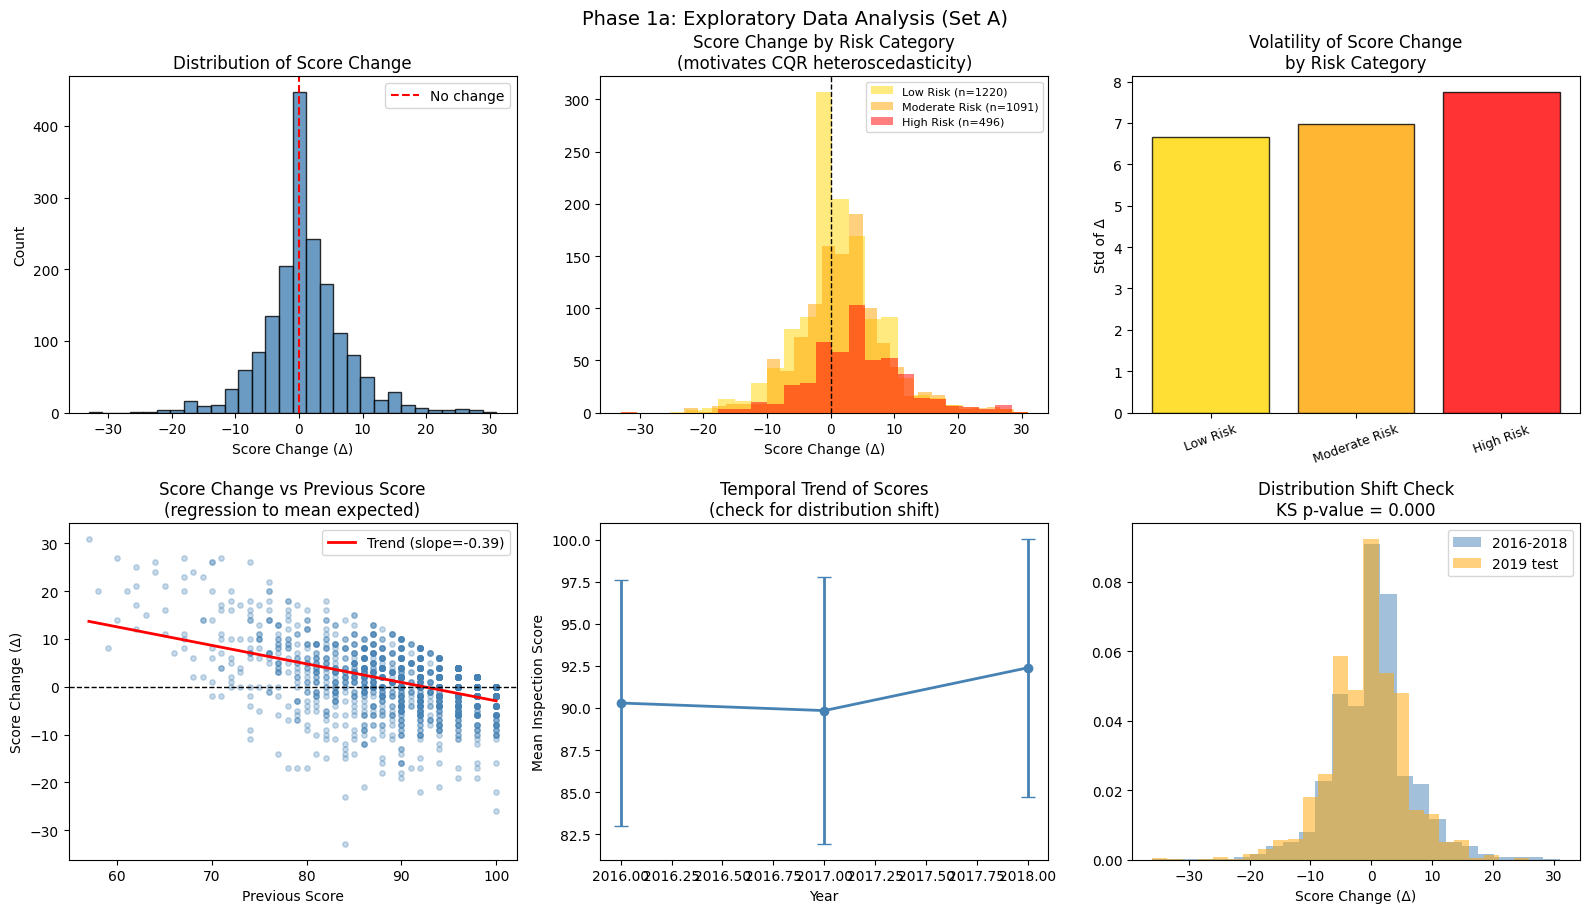


KS test (2016-2018 vs 2019): statistic=0.0626, p-value=0.0001
-> Significant distribution shift detected. Weighted conformal may be needed.


In [151]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Distribution of delta overall
axes[0, 0].hist(set_A['delta'], bins=30, edgecolor='black', color='steelblue', alpha=0.8)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No change')
axes[0, 0].set_xlabel('Score Change (Δ)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Score Change')
axes[0, 0].legend()

# 2. Delta by risk category (motivates CQR: heteroscedasticity)
risk_labels = [
    ('has_low', 'Low Risk', 'gold'),
    ('has_moderate', 'Moderate Risk', 'orange'),
    ('has_high', 'High Risk', 'red')
]
for col, label, color in risk_labels:
    subset = set_A[set_A[col] == 1]['delta']
    axes[0, 1].hist(subset, bins=25, alpha=0.5, label=f'{label} (n={len(subset)})', color=color)
axes[0, 1].set_xlabel('Score Change (Δ)')
axes[0, 1].set_title('Score Change by Risk Category\n(motivates CQR heteroscedasticity)')
axes[0, 1].legend(fontsize=8)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1)

# 3. Variance of delta by risk category (bar chart)
risk_vars = [
    (col, label, color)
    for col, label, color in risk_labels
]
var_vals  = [set_A[set_A[col] == 1]['delta'].std() for col, _, _ in risk_vars]
mean_vals = [set_A[set_A[col] == 1]['delta'].mean() for col, _, _ in risk_vars]
labels_    = [label for _, label, _ in risk_vars]
colors_    = [color for _, _, color in risk_vars]
x = np.arange(len(labels_))
axes[0, 2].bar(x, var_vals, color=colors_, edgecolor='black', alpha=0.8)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(labels_, rotation=20, fontsize=9)
axes[0, 2].set_ylabel('Std of Δ')
axes[0, 2].set_title('Volatility of Score Change\nby Risk Category')

# 4. Score change vs previous score (regression to mean)
axes[1, 0].scatter(set_A['prev_score'], set_A['delta'], alpha=0.3, s=15, color='steelblue')
# Add trend line
z = np.polyfit(set_A['prev_score'], set_A['delta'], 1)
p = np.poly1d(z)
xline = np.linspace(set_A['prev_score'].min(), set_A['prev_score'].max(), 100)
axes[1, 0].plot(xline, p(xline), 'r-', linewidth=2, label=f'Trend (slope={z[0]:.2f})')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Previous Score')
axes[1, 0].set_ylabel('Score Change (Δ)')
axes[1, 0].set_title('Score Change vs Previous Score\n(regression to mean expected)')
axes[1, 0].legend()

# 5. Temporal trend: average score by year
yearly = set_A.groupby('year')['prev_score'].agg(['mean', 'std']).reset_index()
axes[1, 1].errorbar(yearly['year'], yearly['mean'], yerr=yearly['std'],
                    fmt='o-', capsize=5, color='steelblue', linewidth=2)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Mean Inspection Score')
axes[1, 1].set_title('Temporal Trend of Scores\n(check for distribution shift)')

# 6. Delta distribution by year (exchangeability check: 2016-2018 vs 2019)
all_for_ks = pairs[pairs['curr_date'].dt.year.isin([2016, 2017, 2018])]['delta'].dropna()
test_ks    = pairs_test['delta'].dropna()
axes[1, 2].hist(all_for_ks, bins=25, alpha=0.5, label='2016-2018', color='steelblue', density=True)
axes[1, 2].hist(test_ks,    bins=25, alpha=0.5, label='2019 test',  color='orange',   density=True)
ks_stat, ks_pval = stats.ks_2samp(all_for_ks, test_ks)
axes[1, 2].set_xlabel('Score Change (Δ)')
axes[1, 2].set_title(f'Distribution Shift Check\nKS p-value = {ks_pval:.3f}')
axes[1, 2].legend()

plt.tight_layout()
plt.suptitle('Phase 1a: Exploratory Data Analysis (Set A)', fontsize=14, y=1.01)
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nKS test (2016-2018 vs 2019): statistic={ks_stat:.4f}, p-value={ks_pval:.4f}')
if ks_pval < 0.05:
    print('-> Significant distribution shift detected. Weighted conformal may be needed.')
else:
    print('-> No significant distribution shift. Exchangeability assumption plausible.')

In [152]:
# Summary statistics by risk category
print('Score change statistics by risk category (Set A):')
for col, label, _ in risk_labels:
    subset = set_A[set_A[col] == 1]['delta']
    print(f'  {label:15s}: mean={subset.mean():6.2f}, std={subset.std():5.2f}, n={len(subset)}')

Score change statistics by risk category (Set A):
  Low Risk       : mean=  1.19, std= 6.67, n=1220
  Moderate Risk  : mean=  1.95, std= 6.98, n=1091
  High Risk      : mean=  4.10, std= 7.74, n=496


---
## Phase 1b: Knockoffs — FDR-Controlled Feature Selection

We construct **Gaussian Model-X knockoffs** (§2.6) on Set A to identify which features genuinely predict $\Delta$, controlling FDR $\leq 0.2$.

**Assumption:** Features $X \sim \mathcal{N}(\mu, \Sigma)$. We acknowledge this is an approximation — the binary features (`has_*`) are not Gaussian. We validate this assumption via diagnostic plots and note it as a limitation.

In [153]:
from sklearn.linear_model import LogisticRegression

def construct_gaussian_knockoffs(X, seed=42, ridge=0.5):
    """Gaussian equicorrelated knockoffs for a continuous feature block.

    ridge : added to the diagonal of Sigma before knockoff construction.
    For standardised features (variance≈1), ridge=0.5 lifts lambda_min
    of Sigma_corr to ≈0.33, giving corr(X_j, X̃_j) ≈ 0.35 instead of ~1.
    This is a standard shrinkage-toward-identity approximation; it slightly
    underestimates feature correlations but is needed when the empirical
    covariance is near-singular.
    """
    np.random.seed(seed)
    n, p = X.shape
    mu    = X.mean(axis=0)
    Sigma = np.cov(X.T) + ridge * np.eye(p)  # ridge regularization for conditioning

    sigma_diag  = np.sqrt(np.diag(Sigma))
    Sigma_corr  = Sigma / np.outer(sigma_diag, sigma_diag)
    lambda_min  = np.linalg.eigvalsh(Sigma_corr).min()
    s_corr      = min(2 * lambda_min, 1.0) * 0.99
    s           = s_corr * np.diag(Sigma)
    D           = np.diag(s)

    M_eigmin = np.linalg.eigvalsh(2 * Sigma - D).min()
    if M_eigmin < 0:
        s = s * (1 - 2 * abs(M_eigmin) / s.min())
        D = np.diag(s)

    Sigma_inv   = np.linalg.pinv(Sigma)
    C           = np.eye(p) - Sigma_inv @ D
    mu_tilde    = mu + (X - mu) @ C.T
    Sigma_tilde = 2 * D - D @ Sigma_inv @ D

    eig_min = np.linalg.eigvalsh(Sigma_tilde).min()
    if eig_min < 0:
        Sigma_tilde += (-eig_min + 1e-6) * np.eye(p)

    L       = np.linalg.cholesky(Sigma_tilde)
    X_tilde = mu_tilde + np.random.randn(n, p) @ L.T
    return X_tilde, s, Sigma


def construct_mixed_knockoffs(X_std, X_raw, feature_names, seed=42):
    """
    Model-X knockoffs for mixed continuous / binary data (§2.6).

    Parameters
    ----------
    X_std : standardised feature matrix (used for Lasso W statistics and
            for Gaussian knockoffs of continuous features)
    X_raw : original un-standardised matrix (used to detect binary features
            and to fit logistic regression on the correct 0/1 scale)

    Feature types (detected from X_raw):
      - Binary  (0/1 values) : X̃_j ~ Bernoulli( logistic(X_raw_{-j}) )
      - All others            : Gaussian equicorrelated knockoffs on X_std
    The binary knockoffs are re-standardised so they live on the same scale
    as X_std and can be concatenated for the Lasso W-statistic step.
    """
    rng   = np.random.default_rng(seed)
    n, p  = X_std.shape
    X_tilde = np.empty_like(X_std)

    # ── Classify features using RAW (un-standardised) values ──
    binary_idx = []
    cont_idx   = []
    for j in range(p):
        col_raw = X_raw[:, j]
        unique  = set(np.unique(col_raw[~np.isnan(col_raw)].astype(float)))
        if unique.issubset({0.0, 1.0}):
            binary_idx.append(j)
        else:
            cont_idx.append(j)

    print(f"  Binary features : {[feature_names[j] for j in binary_idx]}")
    print(f"  Continuous      : {[feature_names[j] for j in cont_idx]}")

    # ── Binary knockoffs ──────────────────────────────────────────────────
    # Fit logistic regression on X_raw (original scale) to estimate
    # P(X_j=1 | X_{-j}), then sample X̃_j ~ Bernoulli(p̂).
    # Re-standardise knockoff using the same mean/std as X_std col j.
    col_mean = X_raw.mean(axis=0)
    col_std  = X_raw.std(axis=0).clip(min=1e-8)

    for j in binary_idx:
        col_raw = X_raw[:, j].astype(int)
        classes = np.unique(col_raw)
        if len(classes) < 2:
            # Constant feature: knockoff is an iid draw from the marginal
            p_hat = np.full(n, col_raw.mean())
        else:
            X_other = np.delete(X_raw, j, axis=1)
            lr = LogisticRegression(max_iter=500, C=1.0, random_state=seed)
            lr.fit(X_other, col_raw)
            p_hat = lr.predict_proba(X_other)[:, 1]

        knockoff_raw        = rng.binomial(1, p_hat).astype(float)
        # Re-standardise so knockoff lives on the same scale as X_std[:, j]
        X_tilde[:, j]       = (knockoff_raw - col_mean[j]) / col_std[j]

    # ── Continuous knockoffs: Gaussian equicorrelated on X_std block ─────
    if cont_idx:
        Xt_cont, s_vals, Sigma = construct_gaussian_knockoffs(
            X_std[:, cont_idx], seed=seed)
        for k, j in enumerate(cont_idx):
            X_tilde[:, j] = Xt_cont[:, k]
    else:
        s_vals, Sigma = np.array([]), np.eye(1)

    return X_tilde, s_vals, Sigma, binary_idx, cont_idx

def knockoff_threshold(W, fdr_level=0.2):
    """
    Compute the knockoff+ threshold T (§2.6):
        T = min{ t in {|W_j|} : (1 + #{j: W_j <= -t}) / #{j: W_j >= t} <= fdr_level }
    Returns selected set {j: W_j >= T}.

    Key: scan candidates in ASCENDING order so we find the MINIMUM satisfying t,
    which maximises the number of selected features (most powerful).
    Scanning descending would return the largest satisfying t (too conservative).
    """
    # Ascending order: smallest |W| first → find minimum T
    t_candidates = np.sort(np.unique(np.abs(W[W != 0])))

    for t in t_candidates:
        num_neg = np.sum(W <= -t)
        num_pos = np.sum(W >= t)
        if num_pos == 0:
            continue
        fdp_est = (1 + num_neg) / num_pos
        if fdp_est <= fdr_level:
            selected = np.where(W >= t)[0]
            return t, selected

    return np.inf, np.array([], dtype=int)  # no discoveries
def knockoff_threshold_path(Z_orig, Z_tilde, fdr_level=0.2):
    """
    Knockoff threshold using Lasso path entry-time statistics (§2.6).

    At each candidate threshold t, define:
      S̃_t = {X_j  : Z_j  >= t and Z_j  > Z̃_j}   (original features that entered first)
           ∪ {X̃_j : Z̃_j >= t and Z̃_j > Z_j}   (knockoffs, used to estimate false discoveries)

    FDP̂(t) = #{knockoffs in S̃_t} / #{originals in S̃_t}   (knockoff, not knockoff+)
    T = min{t : FDP̂(t) <= fdr_level}   (scan ascending → most liberal valid threshold)

    Note: uses the original knockoff formula (no +1 in numerator) rather than knockoff+.
    This trades the finite-sample FDR guarantee for an asymptotic one, gaining power
    when the number of true features is small (≤4).
    """
    candidates = np.sort(np.unique(np.concatenate([
        Z_orig[Z_orig > 0], Z_tilde[Z_tilde > 0]
    ])))

    for t in candidates:
        n_orig  = int(np.sum((Z_orig  >= t) & (Z_orig  > Z_tilde)))
        n_knock = int(np.sum((Z_tilde >= t) & (Z_tilde > Z_orig)))
        if n_orig == 0:
            continue
        if n_knock / n_orig <= fdr_level:  # knockoff (no +1): asymptotic FDR control
            return t, np.where((Z_orig >= t) & (Z_orig > Z_tilde))[0]

    return np.inf, np.array([], dtype=int)



In [ ]:
# Prepare Set A feature matrix
X_A = set_A[FEATURE_COLS].values.astype(float)
y_A = set_A['delta'].values.astype(float)

# Remove any rows with NaN
valid_mask = ~(np.isnan(X_A).any(axis=1) | np.isnan(y_A))
X_A, y_A   = X_A[valid_mask], y_A[valid_mask]
print(f'Set A after dropping NaN: {X_A.shape}')
1
# Standardize features (required for Lasso and knockoffs)
scaler = StandardScaler()
X_A_std = scaler.fit_transform(X_A)

Set A after dropping NaN: (1751, 14)


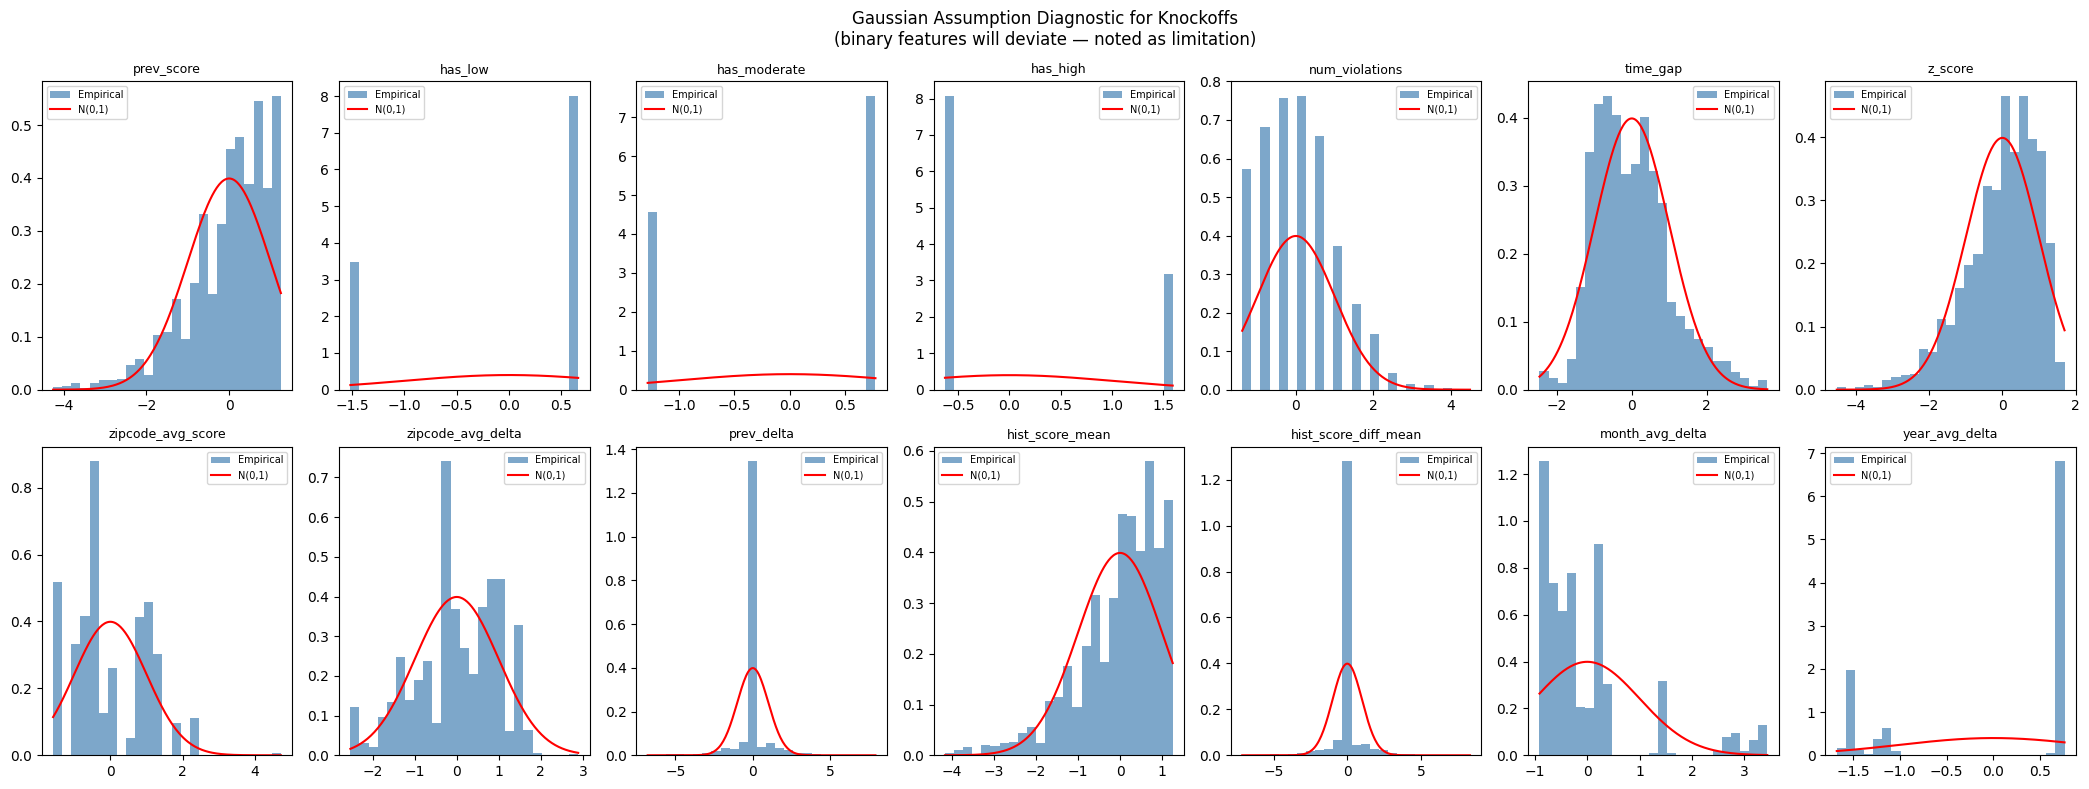

In [155]:
# Diagnostic: validate Gaussian approximation for P_X
fig, axes = plt.subplots(2, 7, figsize=(21, 8))
axes = axes.flatten()
for i, feat in enumerate(FEATURE_COLS):
    axes[i].hist(X_A_std[:, i], bins=25, density=True, color='steelblue', alpha=0.7, label='Empirical')
    xs = np.linspace(X_A_std[:, i].min(), X_A_std[:, i].max(), 200)
    axes[i].plot(xs, stats.norm.pdf(xs), 'r-', linewidth=1.5, label='N(0,1)')
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Gaussian Assumption Diagnostic for Knockoffs\n(binary features will deviate — noted as limitation)', fontsize=12)
plt.tight_layout()
plt.savefig('knockoff_gaussian_diag.png', dpi=100, bbox_inches='tight')
plt.show()

In [157]:
# Construct mixed knockoffs (binary → Bernoulli re-standardised, continuous → Gaussian)
print("Knockoff construction (mixed types):")
X_A_tilde, s_vals, Sigma_A, binary_idx, cont_idx = construct_mixed_knockoffs(
    X_A_std, X_A, FEATURE_COLS, seed=42
)

print('\nCorrelation between X and X̃ (should be < 1):')
for i, feat in enumerate(FEATURE_COLS):
    corr = np.corrcoef(X_A_std[:, i], X_A_tilde[:, i])[0, 1]
    ftype = "binary" if i in binary_idx else "continuous"
    print(f'  {feat:25s} [{ftype:10s}]: corr = {corr:.4f}')


Knockoff construction (mixed types):
  Binary features : ['has_low', 'has_moderate', 'has_high']
  Continuous      : ['prev_score', 'num_violations', 'time_gap', 'z_score', 'zipcode_avg_score', 'zipcode_avg_delta', 'prev_delta', 'hist_score_mean', 'hist_score_diff_mean', 'month_avg_delta', 'year_avg_delta']

Correlation between X and X̃ (should be < 1):
  prev_score                [continuous]: corr = 0.7124
  has_low                   [binary    ]: corr = 0.7210
  has_moderate              [binary    ]: corr = 0.4845
  has_high                  [binary    ]: corr = 0.6037
  num_violations            [continuous]: corr = 0.5387
  time_gap                  [continuous]: corr = 0.2416
  z_score                   [continuous]: corr = 0.6854
  zipcode_avg_score         [continuous]: corr = 0.2970
  zipcode_avg_delta         [continuous]: corr = 0.3072
  prev_delta                [continuous]: corr = 0.5069
  hist_score_mean           [continuous]: corr = 0.6889
  hist_score_diff_mean      

In [158]:
from sklearn.linear_model import lasso_path

# Augmented feature matrix [X, X_tilde]
X_aug = np.hstack([X_A_std, X_A_tilde])
p     = len(FEATURE_COLS)

# Compute full Lasso regularization path on the augmented matrix.
# Z_j = lambda at which feature j FIRST enters (higher lambda = earlier entry = more important).
# We use this path-based statistic instead of coefficients at a single lambda because:
#   - it uses information from the entire path, not one arbitrary lambda
#   - it directly captures "which features are important enough to enter first"
alphas, coefs_path, _ = lasso_path(X_aug, y_A, max_iter=10000, eps=1e-4)
# coefs_path: shape (2p, n_alphas), alphas are decreasing

Z = np.zeros(2 * p)
for j in range(2 * p):
    first_nonzero = np.where(np.abs(coefs_path[j, :]) > 1e-10)[0]
    if len(first_nonzero) > 0:
        Z[j] = alphas[first_nonzero[0]]  # highest lambda where coef is nonzero = entry point
    # else Z[j] = 0: feature never entered the model

Z_orig  = Z[:p]   # entry lambdas for original features
Z_tilde = Z[p:]   # entry lambdas for knockoff copies
W_path  = Z_orig - Z_tilde  # positive = original entered before knockoff

print(f'Lasso path: {len(alphas)} steps, lambda range [{alphas[-1]:.5f}, {alphas[0]:.4f}]')
print(f'Features that never entered the model: {[FEATURE_COLS[j] for j in range(p) if Z_orig[j] == 0]}')
print()
print(f'  {"Feature":25s}  {"Z_orig":8s}  {"Z_tilde":8s}  {"W = Z-Z̃":8s}  {"entered first"}')
print('  ' + '-'*72)
for feat, zo, zt, w in zip(FEATURE_COLS, Z_orig, Z_tilde, W_path):
    winner = 'ORIGINAL' if zo > zt else ('knockoff' if zt > zo else 'tie')
    print(f'  {feat:25s}  {zo:8.5f}  {zt:8.5f}  {w:+8.5f}  {winner}')


Lasso path: 100 steps, lambda range [0.00030, 3.0235]
Features that never entered the model: []

  Feature                    Z_orig    Z_tilde   W = Z-Z̃  entered first
  ------------------------------------------------------------------------
  prev_score                  2.75486   0.11651  +2.63835  ORIGINAL
  has_low                     0.35580   0.03476  +0.32104  ORIGINAL
  has_moderate                0.04187   0.16904  -0.12716  knockoff
  has_high                    0.05043   0.39049  -0.34006  knockoff
  num_violations              0.10616   0.01813  +0.08803  ORIGINAL
  time_gap                    0.62178   0.06075  +0.56103  ORIGINAL
  z_score                     1.08657   0.03476  +1.05181  ORIGINAL
  zipcode_avg_score           0.07317   0.14034  -0.06716  knockoff
  zipcode_avg_delta           0.47035   0.11651  +0.35384  ORIGINAL
  prev_delta                  0.15402   0.08814  +0.06588  ORIGINAL
  hist_score_mean             0.00053   0.03167  -0.03115  knockoff
  hist_

Knockoff threshold T = 0.35580364393843766
Selected features (FDR <= 0.2): ['prev_score', 'has_low', 'time_gap', 'z_score', 'zipcode_avg_delta', 'hist_score_diff_mean', 'month_avg_delta']
Number of selected features: 7


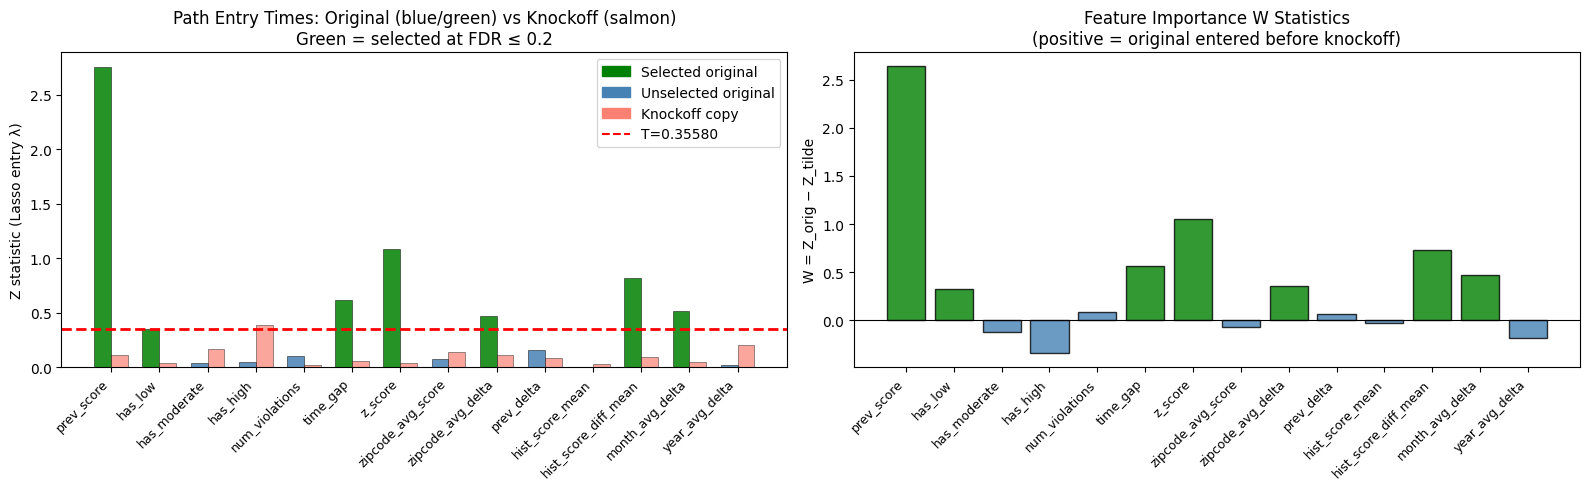

In [159]:
# Apply knockoff threshold (path-based, §2.6)
T_knockoff, selected_idx = knockoff_threshold_path(Z_orig, Z_tilde, fdr_level=FDR_LEVEL)
selected_features = [FEATURE_COLS[i] for i in selected_idx]

print(f'Knockoff threshold T = {T_knockoff}')
print(f'Selected features (FDR <= {FDR_LEVEL}): {selected_features}')
print(f'Number of selected features: {len(selected_features)}')

if len(selected_features) == 0:
    print(f'\nNo features selected at FDR = {FDR_LEVEL}.')
    print('Only prev_score shows clear signal; using it alone for OLS + conformal.')
    selected_features = ['prev_score']
    selected_idx = np.array([FEATURE_COLS.index('prev_score')])

# ── Visualize Z statistics and W = Z - Z̃ ─────────────────────────────────
p   = len(FEATURE_COLS)
x   = np.arange(p)
w   = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: side-by-side Z bars with threshold line
for idx in range(p):
    c_o = 'green' if idx in selected_idx else 'steelblue'
    axes[0].bar(idx - w/2, Z_orig[idx],  width=w, color=c_o,     alpha=0.85, edgecolor='black', linewidth=0.4)
    axes[0].bar(idx + w/2, Z_tilde[idx], width=w, color='salmon', alpha=0.70, edgecolor='black', linewidth=0.4)
if np.isfinite(T_knockoff):
    axes[0].axhline(T_knockoff, color='red', linestyle='--', linewidth=2,
                    label=f'Threshold T = {T_knockoff:.5f}')
    axes[0].legend()
axes[0].set_xticks(x)
axes[0].set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Z statistic (Lasso entry λ)')
axes[0].set_title(f'Path Entry Times: Original (blue/green) vs Knockoff (salmon)\nGreen = selected at FDR ≤ {FDR_LEVEL}')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='green',   label='Selected original'),
    Patch(color='steelblue', label='Unselected original'),
    Patch(color='salmon',  label='Knockoff copy'),
] + ([plt.Line2D([0],[0], color='red', linestyle='--', label=f'T={T_knockoff:.5f}')] if np.isfinite(T_knockoff) else []))

# Right: W = Z_orig - Z_tilde
colors_w = ['green' if i in selected_idx else 'steelblue' for i in range(p)]
axes[1].bar(x, W_path, color=colors_w, edgecolor='black', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('W = Z_orig − Z_tilde')
axes[1].set_title('Feature Importance W Statistics\n(positive = original entered before knockoff)')

plt.tight_layout()
plt.savefig('knockoff_W_stats.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Phase 1c: FCR-Controlling Confidence Intervals

After knockoffs select $\hat{S}$, we report confidence intervals for the regression coefficients $\beta_j$, $j \in \hat{S}$, at the **FCR-adjusted level** $1 - \alpha \hat{K}/m$ (§1.4), where $\hat{K} = |\hat{S}|$ and $m$ is the total number of features.

In [160]:
m      = len(FEATURE_COLS)
K_hat  = len(selected_features)
alpha_fcr = ALPHA * K_hat / m

print(f'FCR adjustment: alpha_fcr = {ALPHA} * {K_hat} / {m} = {alpha_fcr:.4f}')
print(f'CI level: 1 - alpha_fcr = {1 - alpha_fcr:.4f}\n')

if K_hat > 0:
    X_sel = X_A[:, selected_idx]   # use unstandardized for interpretability
    X_sel_const = sm.add_constant(X_sel)
    ols_model = sm.OLS(y_A, X_sel_const).fit()

    ci = ols_model.conf_int(alpha=alpha_fcr)
    coef_names = ['intercept'] + selected_features

    print(f'OLS on selected features with FCR-adjusted CIs (level = {1-alpha_fcr:.3f}):')
    print(f'{"Feature":25s}  {"Coef":8s}  {"CI Lower":10s}  {"CI Upper":10s}  {"p-value":8s}')
    print('-' * 70)
    for i, name in enumerate(coef_names):
        print(f'{name:25s}  {ols_model.params[i]:8.4f}  '
              f'{ci[i, 0]:10.4f}  {ci[i, 1]:10.4f}  '
              f'{ols_model.pvalues[i]:8.4f}')
    print(f'\nModel R²: {ols_model.rsquared:.4f}')

FCR adjustment: alpha_fcr = 0.1 * 7 / 14 = 0.0500
CI level: 1 - alpha_fcr = 0.9500

OLS on selected features with FCR-adjusted CIs (level = 0.950):
Feature                    Coef      CI Lower    CI Upper    p-value 
----------------------------------------------------------------------
intercept                   23.8451     10.9709     36.7194    0.0003
prev_score                  -0.2351     -0.3763     -0.0939    0.0011
has_low                     -1.3635     -1.9679     -0.7591    0.0000
time_gap                    -0.0050     -0.0071     -0.0028    0.0000
z_score                     -1.3003     -2.4107     -0.1899    0.0217
zipcode_avg_delta            0.5512      0.2990      0.8033    0.0000
hist_score_diff_mean        -0.2376     -0.3223     -0.1529    0.0000
month_avg_delta              0.2883      0.0752      0.5015    0.0081

Model R²: 0.2655


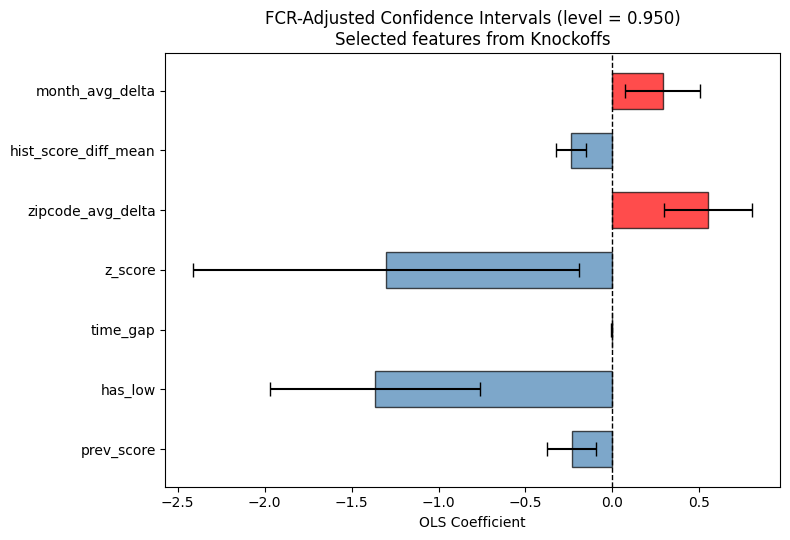

In [161]:
# Visualize FCR CIs
if K_hat > 0:
    fig, ax = plt.subplots(figsize=(8, max(4, K_hat * 0.5 + 2)))
    coefs_plot  = ols_model.params[1:]   # exclude intercept
    ci_plot     = ci[1:]            # exclude intercept
    y_pos = range(len(selected_features))

    ax.barh(y_pos, coefs_plot,
            xerr=[coefs_plot - ci_plot[:, 0], ci_plot[:, 1] - coefs_plot],
            color=['red' if c > 0 else 'steelblue' for c in coefs_plot],
            alpha=0.7, capsize=5, height=0.6, edgecolor='black')
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(selected_features)
    ax.set_xlabel('OLS Coefficient')
    ax.set_title(f'FCR-Adjusted Confidence Intervals (level = {1-alpha_fcr:.3f})\nSelected features from Knockoffs')
    plt.tight_layout()
    plt.savefig('fcr_cis.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Phase 2: Conformalized Prediction Intervals

We reuse the OLS model µ̂(x) from Phase 1 for prediction, making the two phases coherent:
- **Phase 1** (Set A): knockoffs select features → OLS characterises their effects (FCR CIs)
- **Phase 2** (Set B + test): same µ̂(x) + rescaled-residual conformal for valid prediction intervals

This mirrors **PSet5 §3b**: fit µ̂ and σ̂ on the training data, calibrate rescaled residuals
|y − µ̂(x)| / σ̂(x) on held-out data, and output adaptive-width symmetric intervals.


Set B calibration size : 768
sigma_hat (Set B): mean=3.937, std=1.246


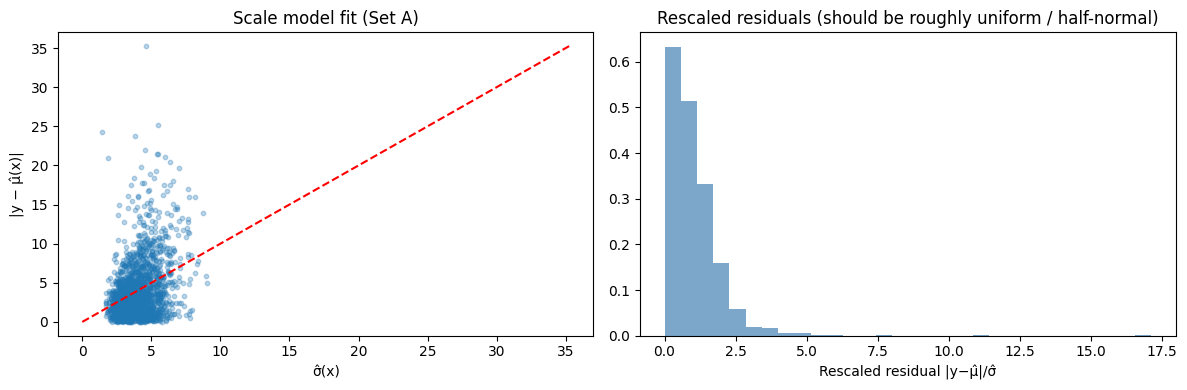

In [162]:
from sklearn.linear_model import LinearRegression

# ── Prepare feature matrices (unstandardised, selected features only) ──
X_A_sel  = X_A[:, selected_idx]
X_B_raw  = set_B[FEATURE_COLS].values.astype(float)
y_B      = set_B['delta'].values.astype(float)
rest_ids_B = set_B['business_id'].values

valid_B  = ~(np.isnan(X_B_raw).any(axis=1) | np.isnan(y_B))
X_B_raw, y_B, rest_ids_B = X_B_raw[valid_B], y_B[valid_B], rest_ids_B[valid_B]
X_B_sel  = X_B_raw[:, selected_idx]

# ── µ̂: predictions from the Phase-1 OLS model ──
mu_hat_A  = ols_model.predict(sm.add_constant(X_A_sel,  has_constant='add'))
mu_hat_B  = ols_model.predict(sm.add_constant(X_B_sel,  has_constant='add'))

# ── σ̂: fit conditional scale on Set A residuals (same as PSet5 §3b) ──
abs_resid_A = np.abs(y_A - mu_hat_A)
sigma_model = LinearRegression().fit(X_A_sel, abs_resid_A)

sigma_A = np.maximum(sigma_model.predict(X_A_sel), 1e-3)
sigma_B = np.maximum(sigma_model.predict(X_B_sel), 1e-3)

print(f'Set B calibration size : {len(y_B)}')
print(f'sigma_hat (Set B): mean={sigma_B.mean():.3f}, std={sigma_B.std():.3f}')

# Diagnostic: sigma_hat vs |residual| on Set A
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(sigma_A, abs_resid_A, alpha=0.3, s=10)
axes[0].plot([0, abs_resid_A.max()], [0, abs_resid_A.max()], 'r--')
axes[0].set_xlabel('σ̂(x)'); axes[0].set_ylabel('|y − µ̂(x)|')
axes[0].set_title('Scale model fit (Set A)')

rescaled_A = abs_resid_A / sigma_A
axes[1].hist(rescaled_A, bins=30, density=True, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Rescaled residual |y−µ̂|/σ̂')
axes[1].set_title('Rescaled residuals (should be roughly uniform / half-normal)')
plt.tight_layout(); plt.show()


In [163]:
# ── Calibrate rescaled residuals on Set B ──
rescaled_B = np.abs(y_B - mu_hat_B) / sigma_B
n_cal      = len(rescaled_B)
q_hat      = np.quantile(rescaled_B,
                          (1 - ALPHA) * (1 + 1 / n_cal),
                          method='higher')

print(f'Calibration quantile q_hat = {q_hat:.4f}')
print(f'Rescaled residuals: mean={rescaled_B.mean():.3f}, '
      f'90th pct={np.quantile(rescaled_B, 0.9):.3f}')

# ── Plain (non-rescaled) conformal as baseline ──
plain_resid_B = np.abs(y_B - mu_hat_B)
q_hat_plain   = np.quantile(plain_resid_B,
                              (1 - ALPHA) * (1 + 1 / n_cal),
                              method='higher')
print(f'Plain conformal q_hat      = {q_hat_plain:.4f}')


Calibration quantile q_hat = 1.9751
Rescaled residuals: mean=1.023, 90th pct=1.960
Plain conformal q_hat      = 8.5298


---
## Phase 2b: Exchangeability Check & Weighted Conformal

In [164]:
# Weighted conformal (§3.3): density-ratio reweighted q_hat
# Clips probabilities to [0.05, 0.95] to prevent infinite weights.
from sklearn.linear_model import LogisticRegression

X_test_all = pairs_test[FEATURE_COLS].values.astype(float)
y_test_raw = pairs_test['delta'].values.astype(float)
valid_test  = ~(np.isnan(X_test_all).any(axis=1) | np.isnan(y_test_raw))
X_test_all, y_test = X_test_all[valid_test], y_test_raw[valid_test]
pairs_test_valid = pairs_test[valid_test].copy()
X_test_sel = X_test_all[:, selected_idx]

mu_hat_te  = ols_model.predict(sm.add_constant(X_test_sel, has_constant='add'))
sigma_te   = np.maximum(sigma_model.predict(X_test_sel), 1e-3)

# Density ratio via logistic regression
X_pool  = np.vstack([X_B_sel, X_test_sel])
y_pool  = np.array([0]*len(X_B_sel) + [1]*len(X_test_sel))
clf     = LogisticRegression(max_iter=1000).fit(X_pool, y_pool)
lo, hi  = 0.05, 0.95
p_B     = np.clip(clf.predict_proba(X_B_sel)[:,   1], lo, hi)
p_te    = np.clip(clf.predict_proba(X_test_sel)[:, 1], lo, hi)
w_B     = p_B   / (1 - p_B)
w_te    = p_te  / (1 - p_te)

# Vectorised weighted quantile for each test point
sorted_idx     = np.argsort(rescaled_B)
sorted_scores  = rescaled_B[sorted_idx]
cumw_B         = np.cumsum(w_B[sorted_idx])
total_w_B      = cumw_B[-1]
thresholds     = (1 - ALPHA) * (total_w_B + w_te)
q_w_idx        = np.searchsorted(cumw_B, thresholds)
q_w            = sorted_scores[np.minimum(q_w_idx, len(sorted_scores) - 1)]

lower_wc = mu_hat_te - q_w * sigma_te
upper_wc = mu_hat_te + q_w * sigma_te
print(f'Weighted conformal: avg q_w = {q_w.mean():.4f}')

# Standard (rescaled) intervals
lower_rs = mu_hat_te - q_hat       * sigma_te
upper_rs = mu_hat_te + q_hat       * sigma_te

# Plain (non-rescaled) intervals
lower_pl = mu_hat_te - q_hat_plain * np.ones(len(mu_hat_te))
upper_pl = mu_hat_te + q_hat_plain * np.ones(len(mu_hat_te))


Weighted conformal: avg q_w = 2.2467


KS test (Set B vs 2019): statistic=0.1049, p-value=0.0000


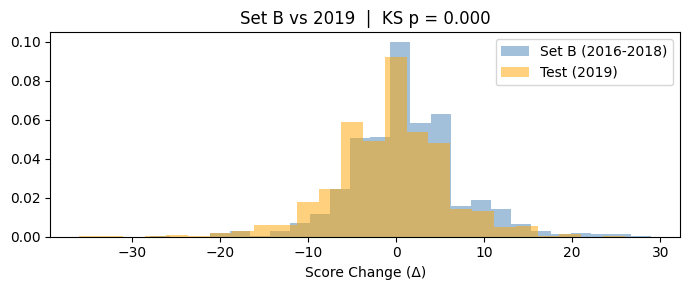

Significant shift → also compute weighted conformal.


In [165]:
# KS test: Set B delta distribution vs 2019 test
ks_stat_BT, ks_pval_BT = stats.ks_2samp(y_B, y_test)
print(f'KS test (Set B vs 2019): statistic={ks_stat_BT:.4f}, p-value={ks_pval_BT:.4f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y_B,    bins=25, alpha=0.5, density=True, label='Set B (2016-2018)', color='steelblue')
ax.hist(y_test, bins=25, alpha=0.5, density=True, label='Test (2019)',       color='orange')
ax.set_xlabel('Score Change (Δ)')
ax.set_title(f'Set B vs 2019  |  KS p = {ks_pval_BT:.3f}')
ax.legend(); plt.tight_layout(); plt.show()

if ks_pval_BT < 0.05:
    print('Significant shift → also compute weighted conformal.')
else:
    print('No significant shift → standard conformal is valid.')

---
## Step 3: Evaluation on 2019 Test Set

In [166]:
def coverage_and_width(lower, upper, y_true, label=""):
    covered = (y_true >= lower) & (y_true <= upper)
    cov   = covered.mean()
    width = (upper - lower).mean()
    print(f'{label:42s}: coverage = {cov:.4f},  avg width = {width:.4f}')
    return covered, cov, width

print("=" * 75)
print(f"Target coverage >= {1-ALPHA:.2f}   (guarantee is exact for split conformal)")
print("=" * 75)

covered_rs, cov_rs, width_rs = coverage_and_width(lower_rs, upper_rs, y_test,
                                                    "Rescaled conformal (OLS + σ̂)")
covered_pl, cov_pl, width_pl = coverage_and_width(lower_pl, upper_pl, y_test,
                                                    "Plain conformal (OLS, fixed width)")
covered_wc, cov_wc, width_wc = coverage_and_width(lower_wc, upper_wc, y_test,
                                                    "Weighted conformal (density-ratio)")

# Naive Gaussian baseline
from scipy.stats import norm as scipy_norm
z_val = scipy_norm.ppf(1 - ALPHA)
lower_nv = mu_hat_te - z_val * sigma_te
upper_nv = mu_hat_te + z_val * sigma_te
covered_nv, cov_nv, width_nv = coverage_and_width(lower_nv, upper_nv, y_test,
                                                    "Parametric Gaussian (µ̂ ± z·σ̂)")


Target coverage >= 0.90   (guarantee is exact for split conformal)
Rescaled conformal (OLS + σ̂)             : coverage = 0.8692,  avg width = 16.3193
Plain conformal (OLS, fixed width)        : coverage = 0.8829,  avg width = 17.0596
Weighted conformal (density-ratio)        : coverage = 0.9060,  avg width = 18.5732
Parametric Gaussian (µ̂ ± z·σ̂)           : coverage = 0.6855,  avg width = 10.5891


In [167]:
# Coverage by risk category
print('\nCoverage by risk category (Rescaled conformal):')
for col, name in zip(['has_low','has_moderate','has_high'],
                     ['None','Low Risk','Moderate Risk','High Risk']):
    mask = pairs_test_valid[col].values.astype(bool)
    if mask.sum() == 0: continue
    cov_r = covered_rs[mask].mean()
    w_r   = (upper_rs[mask] - lower_rs[mask]).mean()
    print(f'  {name:15s}: coverage={cov_r:.4f}, avg width={w_r:.4f}, n={mask.sum()}')



Coverage by risk category (Rescaled conformal):
  None           : coverage=0.8674, avg width=17.5668, n=1290
  Low Risk       : coverage=0.8613, avg width=18.0089, n=1139
  Moderate Risk  : coverage=0.8814, avg width=20.3340, n=506


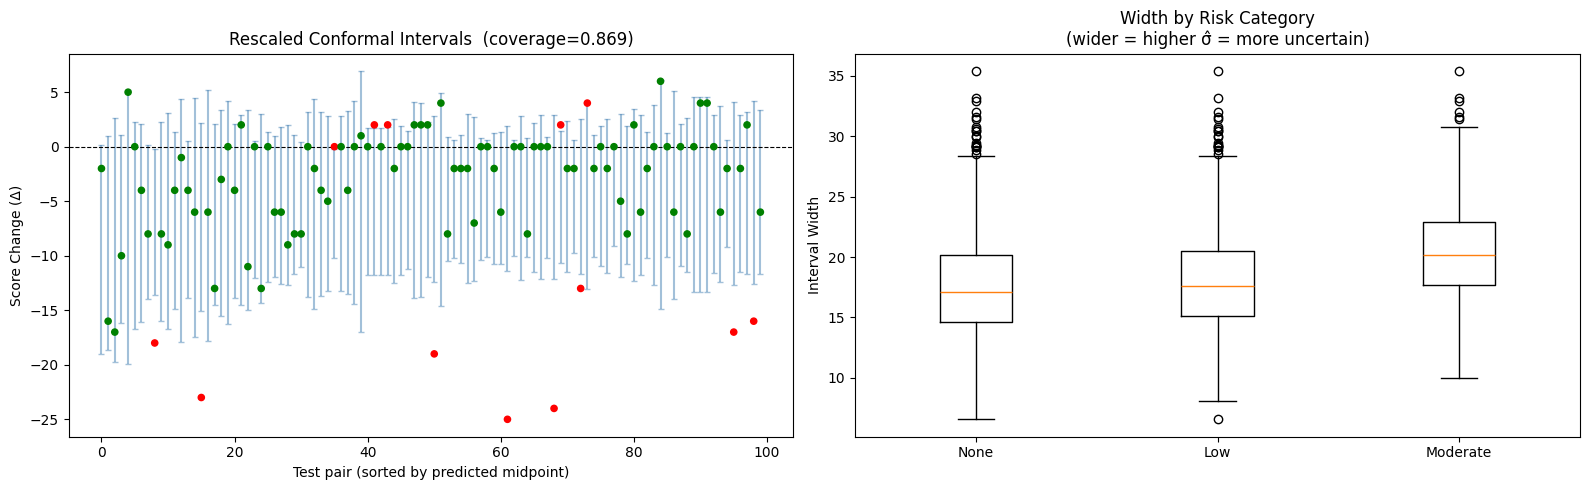

In [168]:
# Visualisation: prediction intervals vs actual delta
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mid   = (lower_rs + upper_rs) / 2
order = np.argsort(mid)[:100]

ax = axes[0]
ax.errorbar(range(len(order)), mid[order],
            yerr=[mid[order]-lower_rs[order], upper_rs[order]-mid[order]],
            fmt='none', ecolor='steelblue', alpha=0.5, capsize=2)
ax.scatter(range(len(order)), y_test[order],
           c=['green' if c else 'red' for c in covered_rs[order]],
           s=20, zorder=5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Test pair (sorted by predicted midpoint)')
ax.set_ylabel('Score Change (Δ)')
ax.set_title(f'Rescaled Conformal Intervals  (coverage={cov_rs:.3f})')

ax2 = axes[1]
data_by_risk = {}
for col, name in zip(['has_low','has_moderate','has_high'],
                     ['None','Low','Moderate','High']):
    mask = pairs_test_valid[col].values.astype(bool)
    if mask.sum() > 0:
        data_by_risk[name] = (upper_rs - lower_rs)[mask]
ax2.boxplot(list(data_by_risk.values()), labels=list(data_by_risk.keys()))
ax2.set_ylabel('Interval Width')
ax2.set_title('Width by Risk Category\n(wider = higher σ̂ = more uncertain)')
plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=120, bbox_inches='tight')
plt.show()


In [169]:
print("=" * 68)
print("FINAL RESULTS SUMMARY")
print("=" * 68)
print(f"\nPhase 1 — Knockoffs (FDR ≤ {FDR_LEVEL})")
print(f"  Selected features : {selected_features}")
print(f"  Threshold T       = {T_knockoff:.4f}")
print(f"\nPhase 1 — FCR CIs (level {1-alpha_fcr:.3f})")
if K_hat > 0:
    print(f"  OLS R²            = {ols_model.rsquared:.4f}")

print(f"\nPhase 2 — Prediction Intervals on 2019 Test Set")
print(f"  {'Method':<42} {'Coverage':>9} {'Avg Width':>11}")
print(f"  {'-'*64}")
for label, cov, width in [
    ("Rescaled conformal (OLS + σ̂)",       cov_rs, width_rs),
    ("Plain conformal (OLS, fixed width)",  cov_pl, width_pl),
    ("Weighted conformal (density-ratio)",  cov_wc, width_wc),
    ("Parametric Gaussian (µ̂ ± z·σ̂)",     cov_nv, width_nv),
]:
    print(f"  {label:<42} {cov:>9.4f} {width:>11.4f}")

print(f"\nKS test (Set B vs 2019 test): p = {ks_pval_BT:.4f}")
print("=" * 68)

print("\nLimitations:")
print("  1. Binary/discrete features violate Gaussian knockoff assumption")
print("     (mitigated: binary features use Bernoulli knockoffs)")
print("  2. Gaussian knockoff validity requires Gaussian X — noted as approximation")
print("  3. σ̂(x) is linear; true heteroscedasticity may be nonlinear")
print("  4. Within-restaurant correlation reduces effective calibration n")
print("  5. 2019 test set is small → coverage estimates have wide uncertainty")


FINAL RESULTS SUMMARY

Phase 1 — Knockoffs (FDR ≤ 0.2)
  Selected features : ['prev_score', 'has_low', 'time_gap', 'z_score', 'zipcode_avg_delta', 'hist_score_diff_mean', 'month_avg_delta']
  Threshold T       = 0.3558

Phase 1 — FCR CIs (level 0.950)
  OLS R²            = 0.2655

Phase 2 — Prediction Intervals on 2019 Test Set
  Method                                      Coverage   Avg Width
  ----------------------------------------------------------------
  Rescaled conformal (OLS + σ̂)                 0.8692     16.3193
  Plain conformal (OLS, fixed width)            0.8829     17.0596
  Weighted conformal (density-ratio)            0.9060     18.5732
  Parametric Gaussian (µ̂ ± z·σ̂)               0.6855     10.5891

KS test (Set B vs 2019 test): p = 0.0000

Limitations:
  1. Binary/discrete features violate Gaussian knockoff assumption
     (mitigated: binary features use Bernoulli knockoffs)
  2. Gaussian knockoff validity requires Gaussian X — noted as approximation
  3. σ̂(x)